<a href="https://colab.research.google.com/github/ragavan0469-hub/AI-BASED-INTERVIEW-PREPARATION-GUIDE/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow-recommenders
!pip install tensorflow-datasets

In [3]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf

print(tf.__version__)

2.20.0


In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_recommenders as tfrs
import numpy as np

# Load MovieLens dataset
ratings = tfds.load("movielens/100k-ratings", split="train")
movies = tfds.load("movielens/100k-movies", split="train")

# Select useful features
ratings = ratings.map(lambda x: {
    "user_id": x["user_id"],
    "movie_title": x["movie_title"]
})

movies = movies.map(lambda x: x["movie_title"])

# Create vocabularies
user_ids = ratings.batch(100000).map(lambda x: x["user_id"])
movie_titles = movies.batch(1000)

unique_user_ids = np.unique(
    np.concatenate(list(user_ids))
)

unique_movie_titles = np.unique(
    np.concatenate(list(movie_titles))
)

# User Model
user_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=unique_user_ids,
        mask_token=None
    ),
    tf.keras.layers.Embedding(len(unique_user_ids) + 1, 32)
])

# Movie Model
movie_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=unique_movie_titles,
        mask_token=None
    ),
    tf.keras.layers.Embedding(len(unique_movie_titles) + 1, 32)
])

# Retrieval Task
task = tfrs.tasks.Retrieval(
    metrics=tfrs.metrics.FactorizedTopK(
        candidates=movies.batch(128).map(movie_model)
    )
)

# Recommendation Model
class MovielensModel(tfrs.Model):

    def __init__(self, user_model, movie_model):
        super().__init__()
        self.user_model = user_model
        self.movie_model = movie_model
        self.task = task

    def compute_loss(self, features, training=False):

        user_embeddings = self.user_model(features["user_id"])

        positive_movie_embeddings = self.movie_model(
            features["movie_title"]
        )

        return self.task(
            user_embeddings,
            positive_movie_embeddings
        )

# Create model
model = MovielensModel(user_model, movie_model)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(0.1)
)

# Train
model.fit(ratings.batch(4096), epochs=3)

# Create Retrieval Index
index = tfrs.layers.factorized_top_k.BruteForce(
    model.user_model
)

index.index_from_dataset(
    movies.batch(100).map(
        lambda title: (
            title,
            model.movie_model(title)
        )
    )
)

# Get Recommendations
scores, titles = index(
    tf.constant(["42"])
)

print("Recommendations for user 42:")
print(titles[0, :3])

Epoch 1/3
25/25 [==============================] - 47s 2s/step - factorized_top_k/top_1_categorical_accuracy: 7.5000e-04 - factorized_top_k/top_5_categorical_accuracy: 0.0071 - factorized_top_k/top_10_categorical_accuracy: 0.0165 - factorized_top_k/top_50_categorical_accuracy: 0.0980 - factorized_top_k/top_100_categorical_accuracy: 0.1898 - loss: 31866.9861 - regularization_loss: 0.0000e+00 - total_loss: 31866.9861
Epoch 2/3
25/25 [==============================] - 37s 1s/step - factorized_top_k/top_1_categorical_accuracy: 0.0016 - factorized_top_k/top_5_categorical_accuracy: 0.0158 - factorized_top_k/top_10_categorical_accuracy: 0.0339 - factorized_top_k/top_50_categorical_accuracy: 0.1591 - factorized_top_k/top_100_categorical_accuracy: 0.2829 - loss: 30708.7042 - regularization_loss: 0.0000e+00 - total_loss: 30708.7042
Epoch 3/3
25/25 [==============================] - 38s 2s/step - factorized_top_k/top_1_categorical_accuracy: 0.0020 - factorized_top_k/top_5_categorical_accuracy: 0.

In [2]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_recommenders as tfrs
import numpy as np

print("TensorFlow:", tf.__version__)
print("TFRS Working Successfully 🚀")

TensorFlow: 2.21.0
TFRS Working Successfully 🚀


In [4]:
!pip install tensorflow==2.15.0
!pip install tensorflow-recommenders==0.7.3

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [5]:
!pip uninstall -y tensorflow keras
!pip install tensorflow==2.15.0
!pip install tensorflow-recommenders==0.7.3
!pip install tensorflow-datasets

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Found existing installation: keras 3.14.1
Uninstalling keras-3.14.1:
  Successfully uninstalled keras-3.14.1
ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl (572.6 MB)
Using cached keras-3.14.1-py3-none-any.whl (1.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_recommenders as tfrs
import numpy as np

print("TensorFlow:", tf.__version__)
print("TFRS Working Successfully 🚀")

TensorFlow: 2.21.0
TFRS Working Successfully 🚀


In [7]:
!pip install tensorflow==2.15.0
!pip install tensorflow-recommenders==0.7.3
!pip install pandas
!pip install numpy

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [4]:
!pip install -q tensorflow tensorflow-recommenders pandas numpy
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs
import numpy as np
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating   timestamp
0     103    84807     1.5  1604344039
1     436    53519     3.5  1613220455
2     861   172585     5.0  1541206699
3     271   158657     3.0  1501061196
4     107   179845     1.0  1647501532
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [5]:
import pandas as pd

# Load datasets
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# Combine datasets using movieId
combined_df = pd.merge(
    ratings,
    movies,
    on="movieId",
    how="inner"
)

# Display first rows
print(combined_df.head())

# Save combined dataset
combined_df.to_csv(
    "combined_movie_dataset.csv",
    index=False
)

print("Dataset Combined Successfully!")
print("Shape:", combined_df.shape)

   userId  movieId  rating   timestamp                   title  \
0     103    84807     1.5  1604344039         Hideaway (2009)   
1     436    53519     3.5  1613220455      Death Proof (2007)   
2     861   172585     5.0  1541206699  Karlson Returns (1970)   
3     271   158657     3.0  1501061196     Dustbin Baby (2008)   
4     107   179845     1.0  1647501532      Brackenmore (2017)   

                                   genres  
0                                   Drama  
1  Action|Adventure|Crime|Horror|Thriller  
2            Adventure|Animation|Children  
3                          Drama|Thriller  
4                      (no genres listed)  
Dataset Combined Successfully!
Shape: (100000, 6)


In [6]:
combined_df.info()
combined_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100000 non-null  int64  
 1   movieId    100000 non-null  int64  
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  int64  
 4   title      100000 non-null  object 
 5   genres     100000 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


,userId,movieId,rating,timestamp,title,genres
0,103,84807,1.5,1604344039,Hideaway (2009),Drama
1,436,53519,3.5,1613220455,Death Proof (2007),Action|Adventure|Crime|Horror|Thriller
2,861,172585,5.0,1541206699,Karlson Returns (1970),Adventure|Animation|Children
3,271,158657,3.0,1501061196,Dustbin Baby (2008),Drama|Thriller
4,107,179845,1.0,1647501532,Brackenmore (2017),(no genres listed)
5,72,194390,1.0,1512077985,Lake of Dracula (1971),Horror
6,701,563,1.0,1607426979,Germinal (1993),Drama|Romance
7,21,104526,5.0,1663883138,So It Goes (Korsoteoria) (2012),Drama
8,615,80893,1.0,1576999800,Grimm Love (2006),Crime|Drama|Horror|Thriller
9,122,4831,4.0,1615036090,Can't Stop the Music (1980),Comedy|Musical


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
combined_df.to_csv(
    "/content/combined_movie_dataset.csv",
    index=False
)

In [21]:
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

df = pd.read_csv('/content/combined_movie_dataset.csv')

print(df.head())
print(df.shape)
df['userId'] = df['userId'].astype(str)
df['title'] = df['title'].astype(str)

ratings = tf.data.Dataset.from_tensor_slices({
    "user_id": df["userId"].values,
    "movie_title": df["title"].values
})
df['userId'] = df['userId'].astype(str)
df['title'] = df['title'].astype(str)

ratings = tf.data.Dataset.from_tensor_slices({
    "user_id": df["userId"].values,
    "movie_title": df["title"].values
})
user_ids = df["userId"].unique()
movie_titles = df["title"].unique()

print("Users:", len(user_ids))
print("Movies:", len(movie_titles))
user_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=user_ids,
        mask_token=None
    ),
    tf.keras.layers.Embedding(
        len(user_ids)+1,
        64
    )
])
movie_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(
        vocabulary=movie_titles,
        mask_token=None
    ),
    tf.keras.layers.Embedding(
        len(movie_titles)+1,
        64
    )
])
class MovieRecommendationModel(tfrs.Model):

    def __init__(self):
        super().__init__()

        self.user_model = user_model
        self.movie_model = movie_model

        self.task = tfrs.tasks.Retrieval()

    def compute_loss(self, features, training=False):

        user_embeddings = self.user_model(
            features["user_id"]
        )

        movie_embeddings = self.movie_model(
            features["movie_title"]
        )

        return self.task(
            user_embeddings,
            movie_embeddings
        )

tf.random.set_seed(42)

dataset = ratings.shuffle(100000)

train = dataset.take(80000)
test = dataset.skip(80000)

train = train.batch(1024)
test = test.batch(1024)
model = MovieRecommendationModel()

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

history = model.fit(
    train,
    validation_data=test,
    epochs=10
)
results = model.evaluate(
    test,
    return_dict=True
)

print(results)
movies_ds = tf.data.Dataset.from_tensor_slices(
    movie_titles
)

index = tfrs.layers.factorized_top_k.BruteForce(
    model.user_model
)

index.index_from_dataset(
    movies_ds.batch(100).map(
        lambda title:
        (
            title,
            model.movie_model(title)
        )
    )
)
tf.saved_model.save(
    index,
    "/content/movie_recommender_model"
)



# Create movie dataset
movies_ds = tf.data.Dataset.from_tensor_slices(movie_titles)

# Build BruteForce index
index = tfrs.layers.factorized_top_k.BruteForce(
    model.user_model
)

# Generate embeddings first
movie_embeddings = movies_ds.batch(128).map(
    lambda x: model.movie_model(x)
)

# Index movies
index.index_from_dataset(
    tf.data.Dataset.zip(
        (
            movies_ds.batch(128),
            movie_embeddings
        )
    )
)
# Convert movie titles to tensor
movie_tensor = tf.constant(movie_titles)

# Generate embeddings
movie_emb = model.movie_model(movie_tensor)

# Create index
index = tfrs.layers.factorized_top_k.BruteForce(
    model.user_model
)

# Direct # Build recommendation index
index = tfrs.layers.factorized_top_k.BruteForce(
    model.user_model
)

index.index(
    candidates=movie_embeddings,
    identifiers=movie_tensor
)

# Get recommendations
scores, titles = index(
    tf.constant(["10"])
)

print("Top Recommendations:")

for movie in titles[0][:10].numpy():
    print(movie.decode("utf-8"))
import tensorflow_recommenders as tfrs

print(tf.__version__)
print(tfrs.__version__)

ModuleNotFoundError: No module named 'tensorflow_recommenders'

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/combined_movie_dataset.csv")

print(df.head())

   userId  movieId  rating   timestamp                   title  \
0     103    84807     1.5  1604344039         Hideaway (2009)   
1     436    53519     3.5  1613220455      Death Proof (2007)   
2     861   172585     5.0  1541206699  Karlson Returns (1970)   
3     271   158657     3.0  1501061196     Dustbin Baby (2008)   
4     107   179845     1.0  1647501532      Brackenmore (2017)   

                                   genres  
0                                   Drama  
1  Action|Adventure|Crime|Horror|Thriller  
2            Adventure|Animation|Children  
3                          Drama|Thriller  
4                      (no genres listed)  


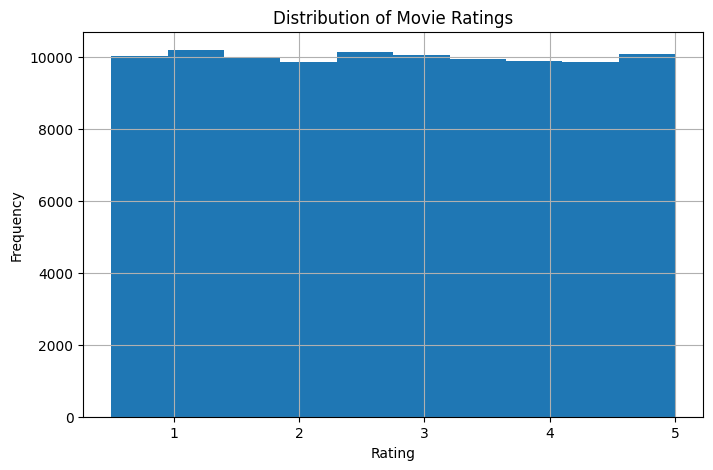

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df["rating"],
    bins=10
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

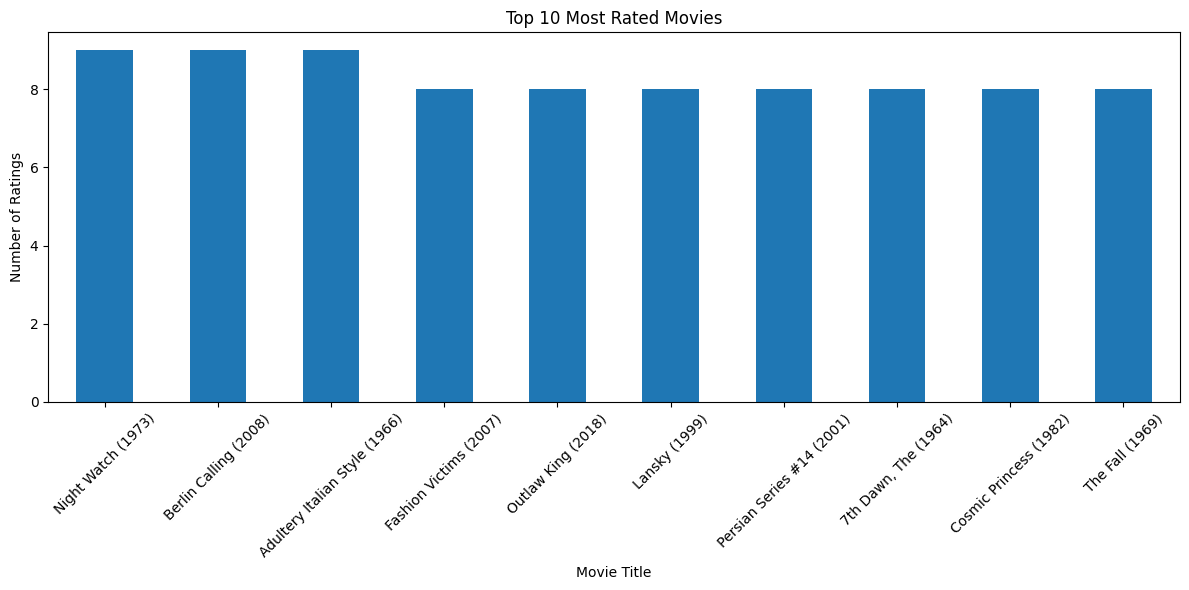

In [14]:
top_movies = (
    df["title"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_movies.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

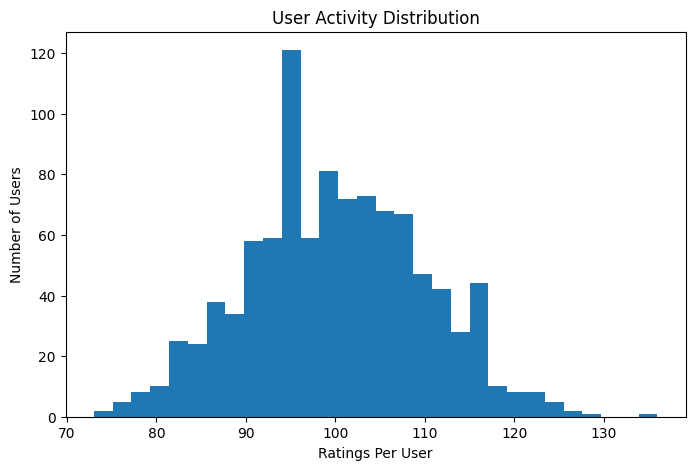

In [15]:
user_activity = (
    df.groupby("userId")
    .size()
)

plt.figure(figsize=(8,5))

plt.hist(
    user_activity,
    bins=30
)

plt.title("User Activity Distribution")
plt.xlabel("Ratings Per User")
plt.ylabel("Number of Users")

plt.show()

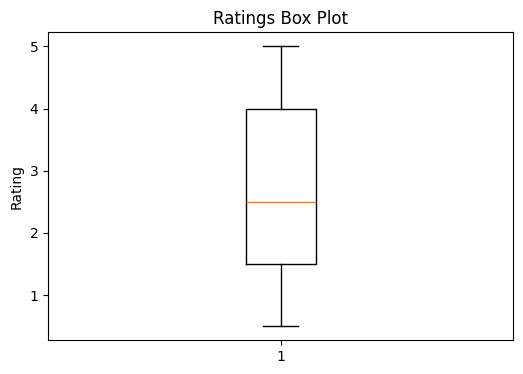

In [16]:
plt.figure(figsize=(6,4))

plt.boxplot(
    df["rating"]
)

plt.title("Ratings Box Plot")
plt.ylabel("Rating")

plt.show()

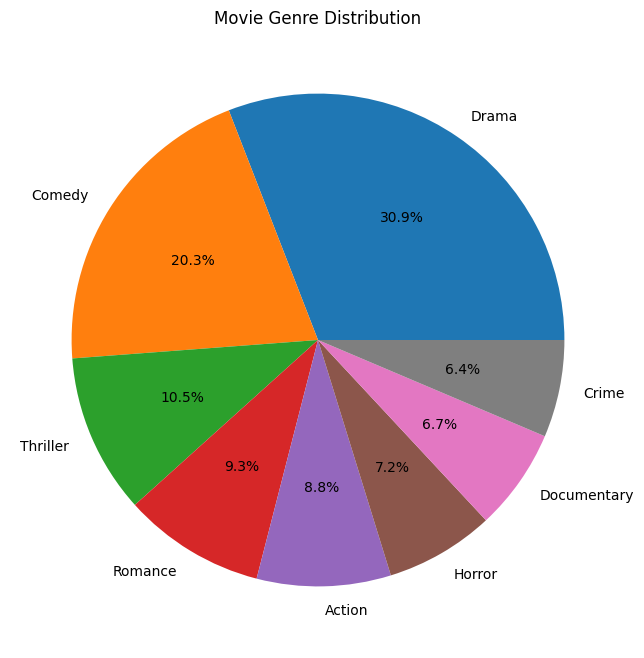

In [17]:
genre_counts = (
    df["genres"]
    .str.split("|")
    .explode()
    .value_counts()
    .head(8)
)

plt.figure(figsize=(8,8))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%"
)

plt.title("Movie Genre Distribution")

plt.show()